# **Parcial tres (3) inteligencia artificial UPB**
Facultad de ciencias exactas, escuela de ingenierias

Nombre: Juan David Parra Sierra
NRC: 000475676

#**Unidad de clasificacion**

A lo largo de este notebook se compraran los algoritmos vistos en clase



In [19]:
!pip install ucimlrepo
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from ucimlrepo import fetch_ucirepo
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

print("Librerías importadas exitosamente!")
print("Versiones principales:")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Sklearn: {sk.__version__}")
print(f"Matplotlib: {mpl.__version__}")

# Fetch the dataset
wine_quality_dataset = fetch_ucirepo(id=186)

# Data (as pandas dataframes)
features = wine_quality_dataset.data.features
targets = wine_quality_dataset.data.targets

Librerías importadas exitosamente!
Versiones principales:
Pandas: 2.2.2
NumPy: 2.0.2
Seaborn: 0.13.2
Sklearn: 1.6.1
Matplotlib: 3.10.0


### **Acción No. 1: Carga y Exploración inicial**

In [20]:
# Action 1: Initial Data Loading and Exploration for Wine Dataset

print("\n📊 Acción No. 1: Carga y Exploración inicial")
print("-" * 60)

# Fetch the dataset again within this cell to ensure it's available
from ucimlrepo import fetch_ucirepo
wine_quality_dataset = fetch_ucirepo(id=186)

# Data (as pandas dataframes)
features = wine_quality_dataset.data.features
targets = wine_quality_dataset.data.targets

# Combine features and targets into a single DataFrame for easier exploration
# Access the original data attribute which includes the 'type' column
full_df = wine_quality_dataset.data.original
df_wine_data = pd.concat([features, targets], axis=1)


# Filter for red wine only
df_red_wine = full_df[full_df['color'] == 'red'].drop('color', axis=1)

# Exclude quality level 9
df_red_wine = df_red_wine[df_red_wine['quality'] != 9]


print("\n=== INFORMACIÓN DEL DATASET (Vino Tinto) ===")
print(f"Forma del dataset (Vino Tinto): {df_red_wine.shape}")
# Exclude the target column for features list
print(f"Características: {list(df_red_wine.columns[:-1])}")
# Explicitly state the target column name
print(f"Clase objetivo: quality")

print("\nPrimeras 5 filas:")
display(df_red_wine.head())

print("\n DISTRIBUCIÓN DE CLASES (Vino Tinto)")
display(df_red_wine['quality'].value_counts().sort_index())


print("\n ESTADÍSTICAS DESCRIPTIVAS (Vino Tinto)")
display(df_red_wine.describe())


📊 Acción No. 1: Carga y Exploración inicial
------------------------------------------------------------

=== INFORMACIÓN DEL DATASET (Vino Tinto) ===
Forma del dataset (Vino Tinto): (1599, 12)
Características: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Clase objetivo: quality

Primeras 5 filas:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



 DISTRIBUCIÓN DE CLASES (Vino Tinto)


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18



 ESTADÍSTICAS DESCRIPTIVAS (Vino Tinto)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### **Acción No. 2: Análisis exploratorio de datos (EDA)**


📊 Acción No. 2: Análisis exploratorio de datos (EDA)
------------------------------------------------------------


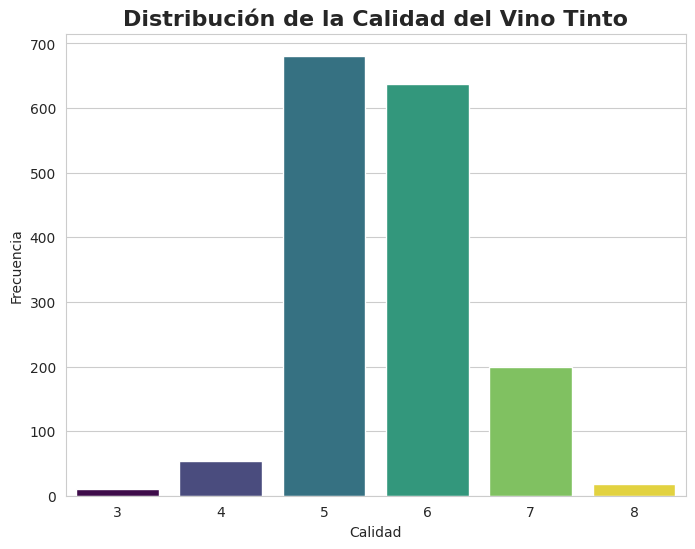


=== Boxplots de Características por Calidad (Vino Tinto) ===


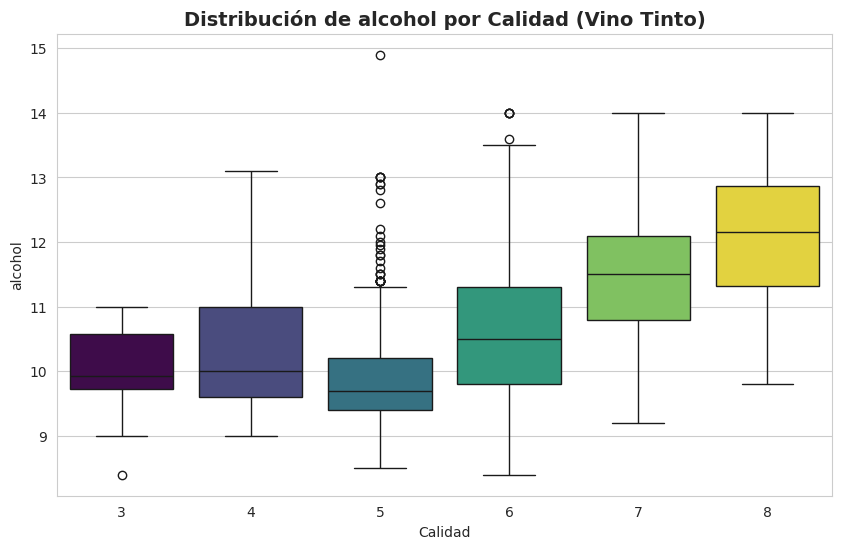

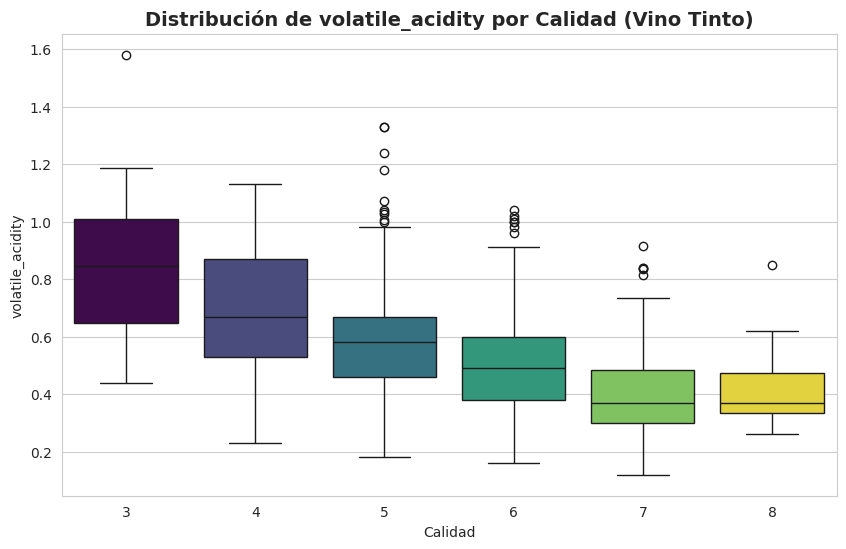

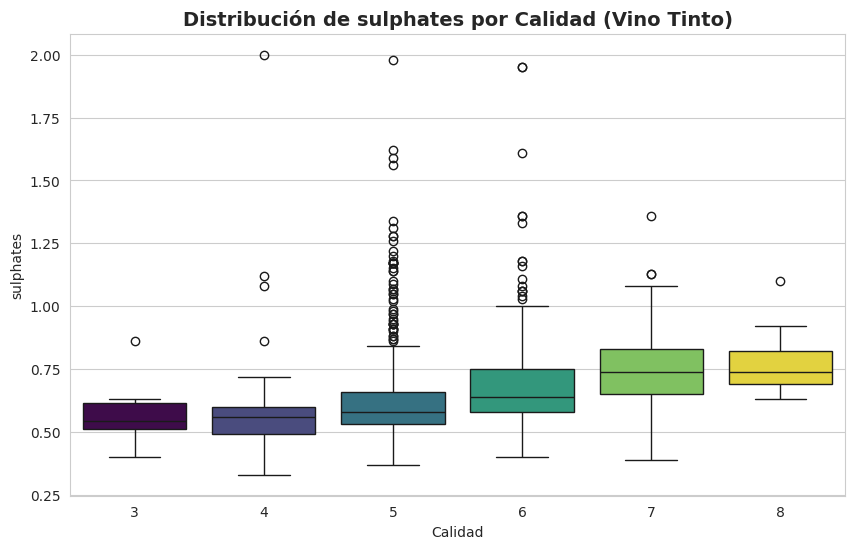


=== Matriz de Correlación (Vino Tinto) ===


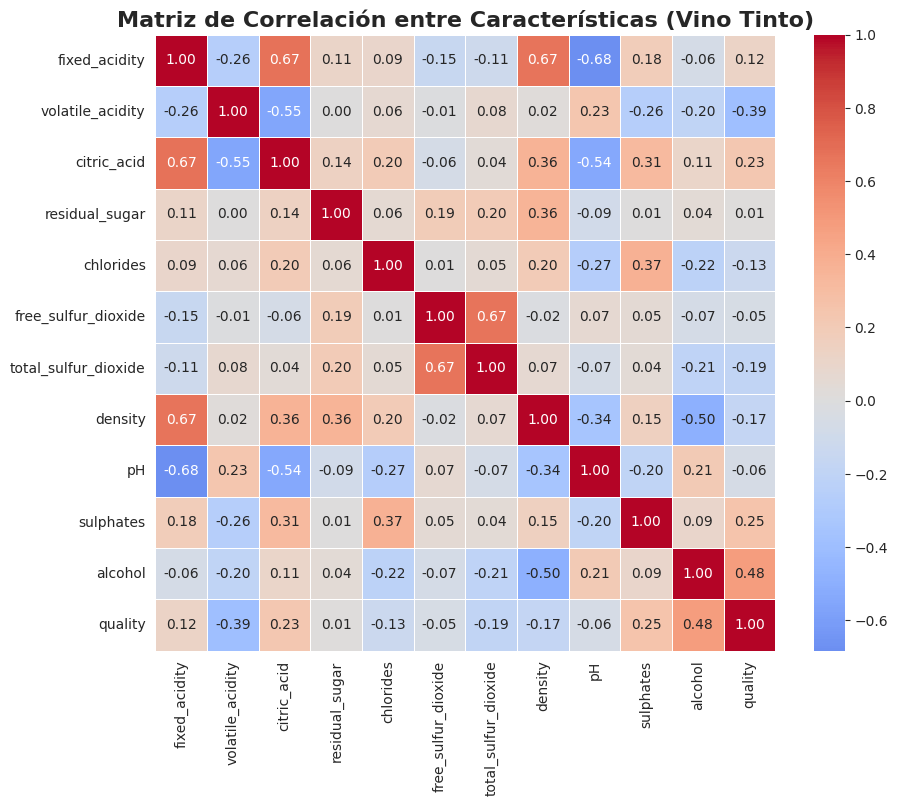


=== Scatter Plot: Alcohol vs Acidez Volátil por Calidad (Vino Tinto) ===


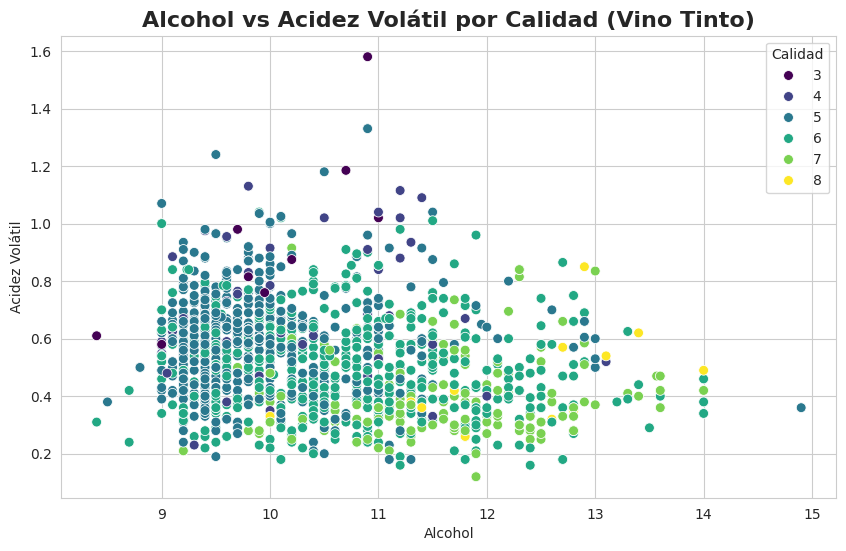



OBSERVACIONES CLAVE DEL EDA (Interpretación inicial):
• Distribución de Calidad: Observa qué niveles de calidad son más frecuentes.
• Boxplots: Analiza cómo varían las características en los diferentes niveles de calidad.
• Matriz de Correlación: Identifica las relaciones entre las características. ¿Qué características se correlacionan más con la calidad?
• Scatter Plot: Visualiza la relación entre pares de características y cómo se agrupan por calidad.


In [21]:
# Action 2: Exploratory Data Analysis (EDA) for Wine Data

print("\n📊 Acción No. 2: Análisis exploratorio de datos (EDA)")
print("-" * 60)

# Set the style for the plots
sns.set_style("whitegrid")

# 1. Distribution of wine quality (target variable)
plt.figure(figsize=(8, 6))
sns.countplot(data=df_red_wine, x='quality', palette='viridis', hue='quality', legend=False) # Corrected dataframe name to df_red_wine
plt.title('Distribución de la Calidad del Vino Tinto', fontsize=16, fontweight='bold') # Added "Tinto" to the title
plt.xlabel('Calidad')
plt.ylabel('Frecuencia')
plt.show()

# 2. Boxplot of features by quality (simplified and separated)
print("\n=== Boxplots de Características por Calidad (Vino Tinto) ===") # Added "Vino Tinto" to the title
selected_features_for_boxplot = ['alcohol', 'volatile_acidity', 'sulphates'] # Added more features to visualize

for feature_name in selected_features_for_boxplot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_red_wine, x='quality', y=feature_name, palette='viridis', hue='quality', legend=False) # Corrected dataframe name to df_red_wine
    plt.title(f'Distribución de {feature_name} por Calidad (Vino Tinto)', fontsize=14, fontweight='bold') # Added "Vino Tinto" and used feature_name
    plt.xlabel('Calidad')
    plt.ylabel(feature_name)
    plt.show()


# 3. Correlation matrix
print("\n=== Matriz de Correlación (Vino Tinto) ===") # Added "Vino Tinto" to the title
plt.figure(figsize=(10, 8))
correlation_matrix_wine = df_red_wine.corr() # Corrected dataframe name to df_red_wine
sns.heatmap(correlation_matrix_wine, annot=True, cmap='coolwarm',
            center=0, fmt=".2f", linewidths=".5")
plt.title('Matriz de Correlación entre Características (Vino Tinto)', fontsize=16, fontweight='bold') # Added "Vino Tinto" to the title
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


# 4. Scatter plot
print("\n=== Scatter Plot: Alcohol vs Acidez Volátil por Calidad (Vino Tinto) ===") # Added "Vino Tinto" to the title
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_red_wine, x='alcohol', y='volatile_acidity', # Corrected dataframe name to df_red_wine
                hue='quality', s=50, palette='viridis')
plt.title('Alcohol vs Acidez Volátil por Calidad (Vino Tinto)', fontsize=16, fontweight='bold') # Added "Vino Tinto" to the title
plt.xlabel('Alcohol')
plt.ylabel('Acidez Volátil')
plt.legend(title='Calidad')
plt.show()


print("\n\nOBSERVACIONES CLAVE DEL EDA (Interpretación inicial):")
print("• Distribución de Calidad: Observa qué niveles de calidad son más frecuentes.")
print("• Boxplots: Analiza cómo varían las características en los diferentes niveles de calidad.")
print("• Matriz de Correlación: Identifica las relaciones entre las características. ¿Qué características se correlacionan más con la calidad?")
print("• Scatter Plot: Visualiza la relación entre pares de características y cómo se agrupan por calidad.")

### **Acción No. 3: Preprocesamiento de datos**

In [22]:
# Action 3: Data Preprocessing for Wine Data

print("\n📊 Acción No. 3: Preprocesamiento de datos")
print("-" * 60)

# Separate features (X) and target variable (y) using the filtered red wine data
X_wine = df_red_wine.drop('quality', axis=1)
y_wine = df_red_wine['quality']

print("=== PREPARACIÓN DE DATOS ===")
print(f"Forma de X (características): {X_wine.shape}")
print(f"Forma de y (objetivo): {y_wine.shape}")

# Split train/test with fixed seed for reproducibility and stratification
# Stratify by y_wine to maintain the distribution of quality levels
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine,
    test_size=0.3,           # 30% for test, 70% for training
    random_state=42,         # Fixed seed for reproducibility
    stratify=y_wine          # Maintain quality class proportion
)

print(f"\n=== DIVISIÓN TRAIN/TEST ===")
print(f"Datos de entrenamiento: {X_train_wine.shape[0]} muestras ({X_train_wine.shape[0]/len(X_wine)*100:.1f}%)")
print(f"Datos de prueba: {X_test_wine.shape[0]} muestras ({X_test_wine.shape[0]/len(X_wine)*100:.1f}%)")

# Verify class distribution in train and test
train_distribution_wine = y_train_wine.value_counts().sort_index()
test_distribution_wine = y_test_wine.value_counts().sort_index()

print(f"\n=== DISTRIBUCIÓN DE CLASES ===")
print("Entrenamiento:", dict(train_distribution_wine)) # Convert Series to dictionary
print("\nPrueba:", dict(test_distribution_wine)) # Convert Series to dictionary


print("\n✓ Datos preparados y divididos correctamente")
print("✓ Estratificación aplicada - distribución de clases de calidad preservada")


📊 Acción No. 3: Preprocesamiento de datos
------------------------------------------------------------
=== PREPARACIÓN DE DATOS ===
Forma de X (características): (1599, 11)
Forma de y (objetivo): (1599,)

=== DIVISIÓN TRAIN/TEST ===
Datos de entrenamiento: 1119 muestras (70.0%)
Datos de prueba: 480 muestras (30.0%)

=== DISTRIBUCIÓN DE CLASES ===
Entrenamiento: {3: np.int64(7), 4: np.int64(37), 5: np.int64(477), 6: np.int64(446), 7: np.int64(139), 8: np.int64(13)}

Prueba: {3: np.int64(3), 4: np.int64(16), 5: np.int64(204), 6: np.int64(192), 7: np.int64(60), 8: np.int64(5)}

✓ Datos preparados y divididos correctamente
✓ Estratificación aplicada - distribución de clases de calidad preservada


### **Acción No. 4: Implementación y Entrenamiento de Modelos**

In [23]:
# Action 4: Model Implementation and Training

print("\n\n🤖 Sección No. 4 - Entrenamiento de modelos")
print("-" * 55)

# Import StandardScaler for data scaling
from sklearn.preprocessing import StandardScaler

# Scale the training and testing data
scaler = StandardScaler()
X_train_wine_scaled = scaler.fit_transform(X_train_wine)
X_test_wine_scaled = scaler.transform(X_test_wine)


# --- Logistic Regression ---
print("\n🔧 Creando modelo de Regresión Logística...")
logistic_regression_model = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter

print("📖 Entrenando el modelo de Regresión Logística...")
logistic_regression_model.fit(X_train_wine_scaled, y_train_wine) # Use scaled data for training

print("✅ ¡Modelo de Regresión Logística entrenado exitosamente!")

# --- Random Forest ---
print("\n🔧 Creando modelo de Random Forest...")
random_forest_model = RandomForestClassifier(random_state=42)

print("📖 Entrenando el modelo de Random Forest...")
random_forest_model.fit(X_train_wine, y_train_wine) # Random Forest does not require scaled data

print("✅ ¡Modelo de Random Forest entrenado exitosamente!")


# --- Support Vector Machine (SVM) ---
print("\n🔧 Creando modelo SVM...")
# Using a linear kernel for simplicity and speed on this dataset
svm_model = SVC(kernel='linear', random_state=42)

print("📖 Entrenando el modelo SVM...")
svm_model.fit(X_train_wine_scaled, y_train_wine) # SVM benefits from scaled data

print("✅ ¡Modelo SVM entrenado exitosamente!")


print("\n🎯 Modelos entrenados y listos para evaluación.")



🤖 Sección No. 4 - Entrenamiento de modelos
-------------------------------------------------------

🔧 Creando modelo de Regresión Logística...
📖 Entrenando el modelo de Regresión Logística...
✅ ¡Modelo de Regresión Logística entrenado exitosamente!

🔧 Creando modelo de Random Forest...
📖 Entrenando el modelo de Random Forest...
✅ ¡Modelo de Random Forest entrenado exitosamente!

🔧 Creando modelo SVM...
📖 Entrenando el modelo SVM...
✅ ¡Modelo SVM entrenado exitosamente!

🎯 Modelos entrenados y listos para evaluación.


### **Acción No. 5: Evaluación de Métricas**



📊 Sección No. 5 - Evaluación de Métricas
-------------------------------------------------------

=== Evaluando Regresión Logística ===
🔮 Haciendo predicciones en datos de prueba (Regresión Logística)...
🎯 Precisión en prueba (Regresión Logística - Accuracy): 60.42%

📈 REPORTE DETALLADO (Regresión Logística):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.66      0.75      0.70       204
           6       0.55      0.64      0.59       192
           7       0.67      0.23      0.35        60
           8       0.00      0.00      0.00         5

    accuracy                           0.60       480
   macro avg       0.31      0.27      0.27       480
weighted avg       0.58      0.60      0.58       480


📋 MATRIZ DE CONFUSIÓN (Regresión Logística):
[[  0   0   2   1   0   0]
 [  0   0  11   5   0   0]
 [  0   1 154  48   1   0]
 [  0   2  64 122

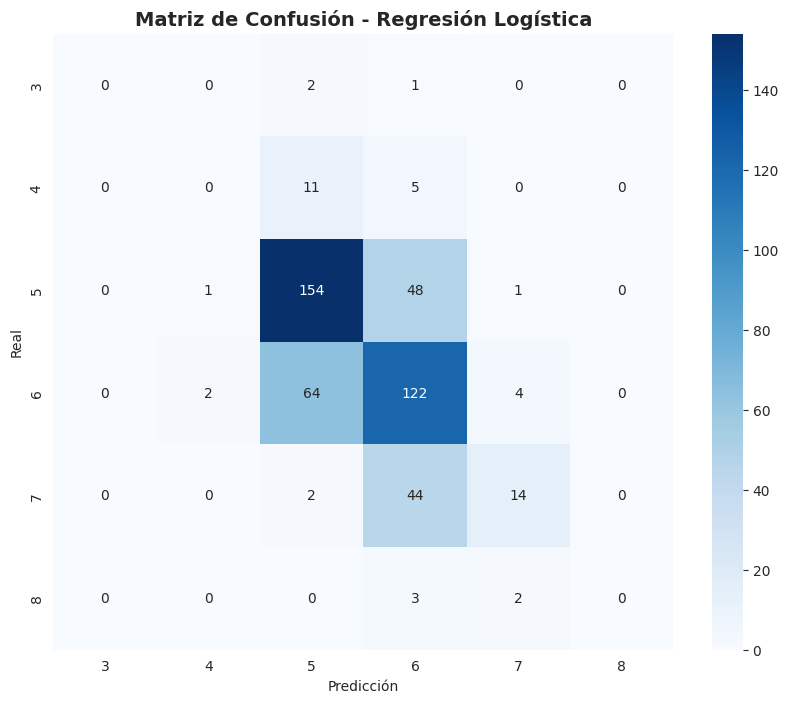


=== Evaluando Random Forest ===
🔮 Haciendo predicciones en datos de prueba (Random Forest)...
🎯 Precisión en prueba (Random Forest - Accuracy): 65.83%

📈 REPORTE DETALLADO (Random Forest):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.71      0.76      0.74       204
           6       0.61      0.71      0.66       192
           7       0.66      0.38      0.48        60
           8       0.50      0.20      0.29         5

    accuracy                           0.66       480
   macro avg       0.41      0.34      0.36       480
weighted avg       0.64      0.66      0.64       480


📋 MATRIZ DE CONFUSIÓN (Random Forest):
[[  0   1   2   0   0   0]
 [  0   0  11   5   0   0]
 [  0   1 156  45   2   0]
 [  0   0  48 136   8   0]
 [  0   0   2  34  23   1]
 [  0   0   0   2   2   1]]


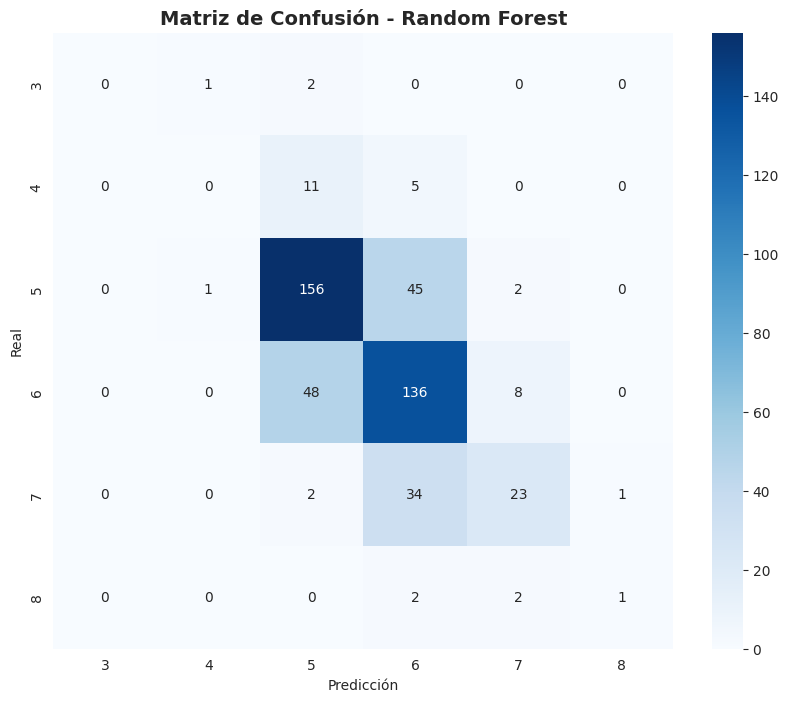


=== Evaluando SVM ===
🔮 Haciendo predicciones en datos de prueba (SVM)...
🎯 Precisión en prueba (SVM - Accuracy): 57.71%

📈 REPORTE DETALLADO (SVM):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.64      0.76      0.70       204
           6       0.51      0.63      0.56       192
           7       0.00      0.00      0.00        60
           8       0.00      0.00      0.00         5

    accuracy                           0.58       480
   macro avg       0.19      0.23      0.21       480
weighted avg       0.48      0.58      0.52       480


📋 MATRIZ DE CONFUSIÓN (SVM):
[[  0   0   2   1   0   0]
 [  0   0  13   3   0   0]
 [  0   0 156  48   0   0]
 [  0   0  71 121   0   0]
 [  0   0   1  59   0   0]
 [  0   0   0   5   0   0]]


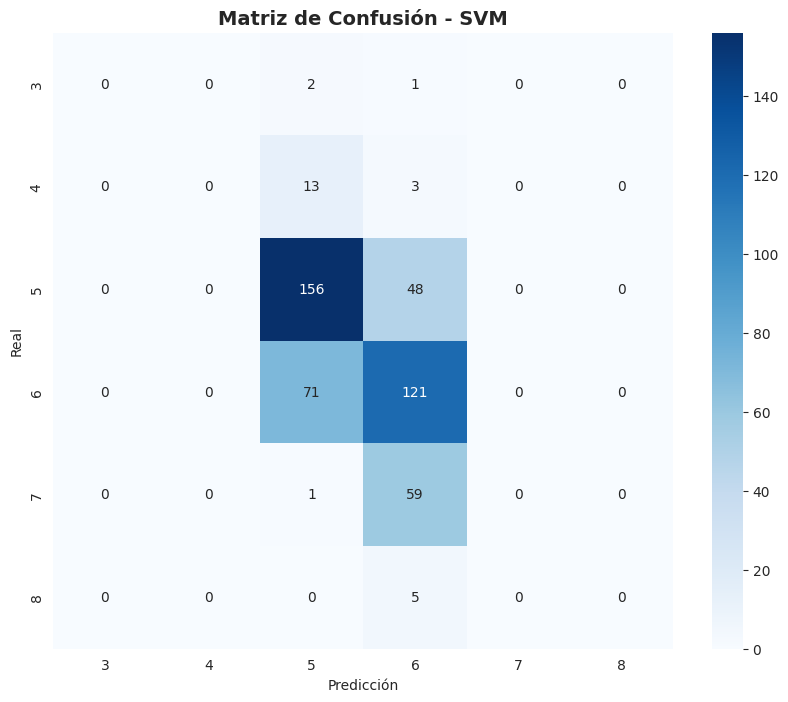



OBSERVACIONES CLAVE DE LA EVALUACIÓN:
• Accuracy: Indica la proporción general de predicciones correctas para cada modelo.
• Reporte de Clasificación: Compara Precision, Recall, y F1-score por clase para cada modelo.
• Matriz de Confusión: Visualiza el rendimiento de cada modelo en cada clase.


In [24]:
print("\n\n📊 Sección No. 5 - Evaluación de Métricas")
print("-" * 55)

# Function to evaluate a model and print metrics
def evaluate_model(model, X_test, y_test, model_name, target_names):
    print(f"\n=== Evaluando {model_name} ===")
    print(f"🔮 Haciendo predicciones en datos de prueba ({model_name})...")
    test_predictions = model.predict(X_test)

    # Overall accuracy
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"🎯 Precisión en prueba ({model_name} - Accuracy): {test_accuracy:.2%}")

    # Detailed classification report
    print(f"\n📈 REPORTE DETALLADO ({model_name}):")
    classification_report_result = classification_report(y_test, test_predictions,
                                target_names=target_names, zero_division=0)
    print(classification_report_result)

    # Create the confusion matrix
    print(f"\n📋 MATRIZ DE CONFUSIÓN ({model_name}):")
    confusion_matrix_result = confusion_matrix(y_test, test_predictions)
    print(confusion_matrix_result)

    # Final visualization: Confusion matrix plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix_result,
                annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.title(f'Matriz de Confusión - {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()


# Get the unique quality levels from the test set to use as target names
target_names = [str(q) for q in sorted(y_test_wine.unique())]

# Evaluate Logistic Regression
evaluate_model(logistic_regression_model, X_test_wine_scaled, y_test_wine, "Regresión Logística", target_names)

# Evaluate Random Forest
evaluate_model(random_forest_model, X_test_wine, y_test_wine, "Random Forest", target_names) # Use unscaled data for Random Forest

# Evaluate SVM
evaluate_model(svm_model, X_test_wine_scaled, y_test_wine, "SVM", target_names) # Use scaled data for SVM


print("\n\nOBSERVACIONES CLAVE DE LA EVALUACIÓN:")
print("• Accuracy: Indica la proporción general de predicciones correctas para cada modelo.")
print("• Reporte de Clasificación: Compara Precision, Recall, y F1-score por clase para cada modelo.")
print("• Matriz de Confusión: Visualiza el rendimiento de cada modelo en cada clase.")

### **Visualización Comparativa: Tiempo de Entrenamiento vs Rendimiento (R²)**




📊 Visualización Comparativa de Rendimiento (Accuracy)
------------------------------------------------------------

=== Recalculando Accuracy para Visualización ===
Accuracy Regresión Logística: 0.60
Accuracy Random Forest: 0.66
Accuracy SVM: 0.58


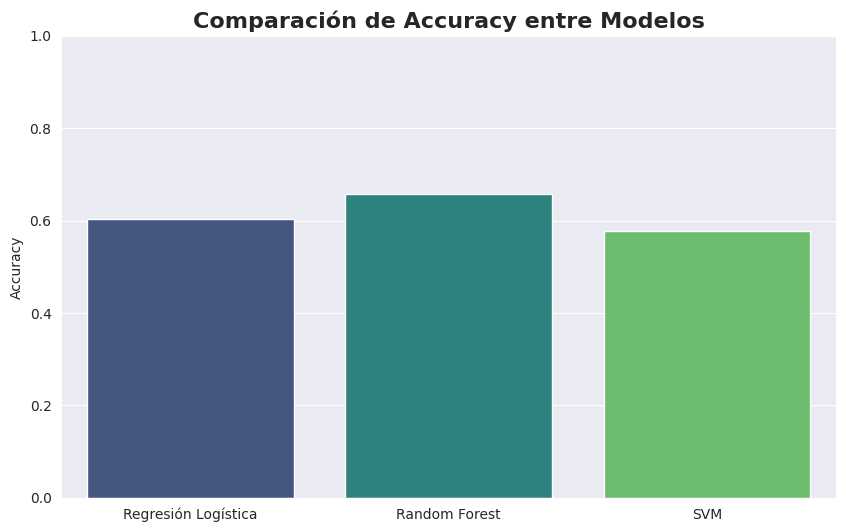


=== Scatter Plot de Rendimiento (Accuracy) ===


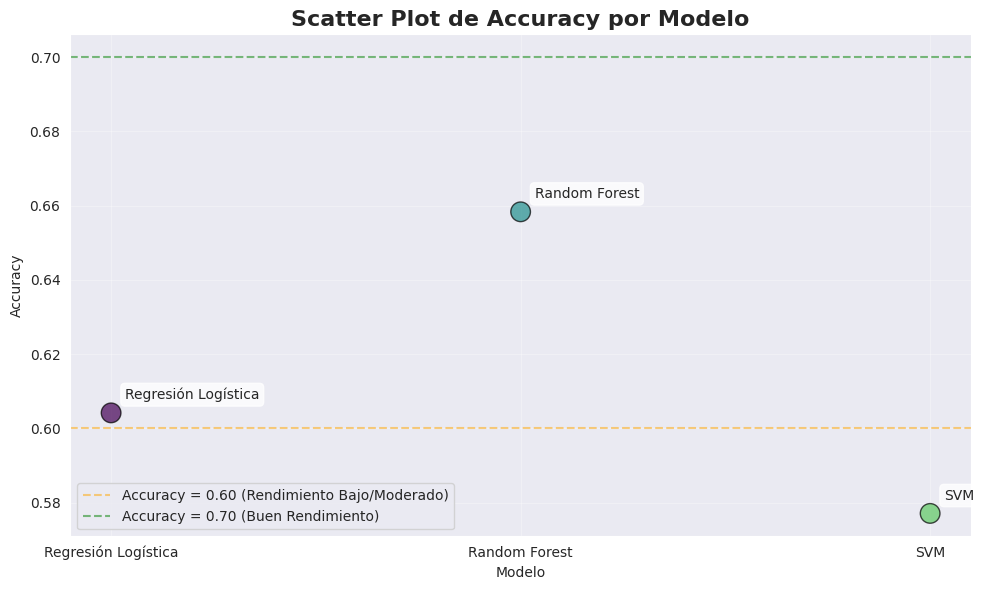


OBSERVACIONES DE LA COMPARACIÓN VISUAL:
• Compara las barras para ver qué modelo alcanzó una mayor precisión en el conjunto de prueba.
• Random Forest parece tener la mayor precisión según los resultados de evaluación previos.


In [26]:
# Comparative Visualization: Model Performance (Accuracy)

print("\n\n📊 Visualización Comparativa de Rendimiento (Accuracy)")
print("-" * 60)

# Get model names
model_names = ["Regresión Logística", "Random Forest", "SVM"]

# Re-evaluate models to get current accuracy scores
# This assumes the models (logistic_regression_model, random_forest_model, svm_model)
# and test data (X_test_wine_scaled, X_test_wine, y_test_wine) are available from previous cells.

print("\n=== Recalculando Accuracy para Visualización ===")

# Evaluate Logistic Regression and capture accuracy
logistic_regression_predictions = logistic_regression_model.predict(X_test_wine_scaled)
logistic_regression_accuracy = accuracy_score(y_test_wine, logistic_regression_predictions)
print(f"Accuracy Regresión Logística: {logistic_regression_accuracy:.2f}")


# Evaluate Random Forest and capture accuracy
random_forest_predictions = random_forest_model.predict(X_test_wine)
random_forest_accuracy = accuracy_score(y_test_wine, random_forest_predictions)
print(f"Accuracy Random Forest: {random_forest_accuracy:.2f}")

# Evaluate SVM and capture accuracy
svm_predictions = svm_model.predict(X_test_wine_scaled)
svm_accuracy = accuracy_score(y_test_wine, svm_predictions)
print(f"Accuracy SVM: {svm_accuracy:.2f}")

# Store accuracy scores in a list
accuracy_scores = [
    logistic_regression_accuracy,
    random_forest_accuracy,
    svm_accuracy
]


# Create a bar chart for comparison
plt.figure(figsize=(10, 6))
# Use a dark grid style for the plot
sns.set_style("darkgrid")
sns.barplot(x=model_names, y=accuracy_scores, palette='viridis', hue=model_names, legend=False) # Added hue and legend=False to resolve FutureWarning
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy entre Modelos', fontsize=16, fontweight='bold')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.show()

# Add a scatter plot for comparison
print("\n=== Scatter Plot de Rendimiento (Accuracy) ===")
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("darkgrid") # Apply dark grid style to this plot as well

# Create scatter points for each model's accuracy
# Using a dummy x-axis value (index) as we don't have training time
ax.scatter(x=[0, 1, 2], y=accuracy_scores, c=['#440154ff', '#21908dff', '#5dc863ff'], s=200, alpha=0.7, edgecolors='black') # Using colors from viridis palette

# Add model labels as annotations next to the points
for i, model in enumerate(model_names):
    ax.annotate(model, (i, accuracy_scores[i]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Set labels and title
ax.set_xlabel('Modelo')
ax.set_ylabel('Accuracy')
ax.set_title('Scatter Plot de Accuracy por Modelo', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1, 2]) # Set x-axis ticks to correspond to the dummy values
ax.set_xticklabels(model_names) # Label x-axis ticks with model names
ax.grid(True, alpha=0.3) # Add grid lines

# Add reference lines (adjust values if necessary for your context)
ax.axhline(y=0.60, color='orange', linestyle='--', alpha=0.5, label='Accuracy = 0.60 (Rendimiento Bajo/Moderado)')
ax.axhline(y=0.70, color='green', linestyle='--', alpha=0.5, label='Accuracy = 0.70 (Buen Rendimiento)')

ax.legend()

plt.tight_layout()
plt.show()


print("\nOBSERVACIONES DE LA COMPARACIÓN VISUAL:")
print("• Compara las barras para ver qué modelo alcanzó una mayor precisión en el conjunto de prueba.")
print("• Random Forest parece tener la mayor precisión según los resultados de evaluación previos.")

# Preguntas sobre algoritmos de clasificacion

## 1. ¿Cual es la principal diferencia entre LogisticRegression y LinearRegression en terminos del tipo de problema que resuleven y su rango de predicciones?

**Linear Regression:**  
Se utiliza para problemas de **regresión**, donde el objetivo es predecir un valor continuo.  
El rango de sus predicciones es cualquier valor real.

**Logistic Regression:**  
Se utiliza para problemas de **clasificación**, donde el objetivo es predecir una categoría o clase.  
El rango de sus predicciones está entre `0` y `1`, interpretadas como probabilidades de pertenecer a una clase positiva (o a una de varias clases en clasificación multiclase).

---

## 2. Entre LogisticRegresssion, Random Forest y SVM, ¿cual algoritmo consideras mas interpretable y por que? ¿En que situaciones esto seria una ventaja importante?

Logistic Regression es generalmente el algoritmo más interpretable de los tres (Logistic Regression, Random Forest, SVM).

**Por qué:**  
En Logistic Regression puedes examinar los coeficientes asignados a cada característica.  
Estos coeficientes indican la dirección y magnitud de la relación entre cada característica y la probabilidad de que la instancia pertenezca a la clase positiva.  

- Un **coeficiente positivo grande** para una característica significa que un aumento en esa característica incrementa significativamente la probabilidad de la clase positiva (manteniendo las demás constantes).

**Ventaja importante:**  
La interpretabilidad es crucial en escenarios donde necesitas entender por qué el modelo tomó una decisión.  
Ejemplos de aplicación:  
- Medicina (factores que contribuyen a una enfermedad).  
- Finanzas (explicación de decisiones de crédito).  
- Justicia (detección de sesgos).  

Si necesitas justificar las decisiones ante partes no técnicas, la interpretabilidad es clave.

---

## 3. ¿Que algoritmo de clasificacion es mas sensible a la escala de caracteristicas (features) y requiere normalizacion o estandarizacion de datos? Explica tu respuesta

El algoritmo **más sensible a la escala** es **SVM**, especialmente con kernels lineales o polinomiales.

**Explicación:**  
SVM busca el hiperplano óptimo que separa las clases.  
Si las características tienen escalas muy distintas, las de valores más grandes dominarán la distancia y moverán el hiperplano de forma sesgada.

- **Solución:** Normalización o estandarización de datos.  
- Logistic Regression también puede beneficiarse de la estandarización, aunque es menos sensible que SVM.  
- Random Forest, al basarse en árboles de decisión, es inherentemente menos sensible a la escala.

---

## 4. Random Forest utiliza multiples arboles de decision. Explica como esta caracteristica ayuda a reducir el overfitting comparado con usar un solo arbol de decision.

Random Forest entrena **múltiples árboles de decisión** en subconjuntos aleatorios de datos y características.

**Cómo reduce el overfitting:**
- **Diversidad de árboles:** Cada árbol comete errores distintos y captura diferentes patrones.  
- **Votación/Promedio:** Las predicciones finales son el resultado de la agregación de todos los árboles (votación para clasificación, promedio para regresión).  
- **Aleatoriedad de características:** Disminuye la correlación entre árboles y mejora la diversidad.

Resultado: un modelo más robusto y generalizable que un árbol de decisión único y profundo.

---

## 5. Imagina que tienes un dataset pequeno (menos de 1000 muestas) con caracteristicas categoricas y numericas mezcladas ¿Que algoritmo de clasificacion elegirias y por que?

Para datasets pequeños (<1000 muestras) con características **categóricas y numéricas**:

- **Random Forest:** Robusto, maneja bien características mixtas (con *One-Hot Encoding* para categóricas), no muy sensible a la escala, menos propenso al overfitting que redes profundas.
- **Gradient Boosting (LightGBM, XGBoost):** Alta precisión, buen manejo de características mixtas y menor riesgo de overfitting si se usa regularización.

### Consideraciones adicionales:
- Si la **interpretabilidad** es crucial: usar un árbol de decisión simple o Logistic Regression (tras preprocesar correctamente).
- Para datasets muy pequeños: también se puede considerar **KNN** después de normalizar o estandarizar.
